# 보험료 예측 - 선형 회귀

의료보험 가입자 데이터(`insurance.csv`)를 이용해, 성별로 데이터를 나눈 뒤 나이(age)·BMI 각각과
보험료(charges) 사이의 관계를 선형 회귀로 살펴보는 실습.

- **Dataset**: `insurance.csv` — 나이(age), 성별(sex), BMI(bmi), 자녀 수(children), 흡연 여부(smoker), 지역(region), 보험료(charges)
- **다루는 내용**: Pandas를 이용한 그룹별 데이터 분리, `LinearRegression`을 이용한 단순 선형 회귀, 회귀 결과 시각화, 클래스를 이용한 로직 캡슐화


## 1. 데이터 로드
csv 파일을 불러와 컬럼 구성과 크기를 확인한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

insurance = pd.read_csv('insurance.csv')
print("행 수:", insurance.shape[0], " 열 수:", insurance.shape[1])
print(insurance.head())


행 수: 1338  열 수: 7
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## 2. 성별 그룹별 회귀 로직 (클래스로 캡슐화)

성별(`female` / `male`)로 데이터를 나눈 뒤, 각 그룹 안에서 age·bmi 각각을 독립변수로 하는 단순 선형 회귀를 적용하고
산점도 + 회귀선을 그리는 로직을 `InsuranceGroup` 클래스로 묶었다.

> 원본 코드에서는 `self = sex`처럼 실제로는 인스턴스에 값을 저장하지 않고, 메서드 안에서 바깥 `for`문의 변수를
> 그대로 참조하는 방식으로 동작하고 있었다 (Python의 스코프 규칙 덕분에 우연히 동작한 케이스). 여기서는
> `self.data`, `self.label`에 명확히 값을 저장하도록 정리해서, 클래스만 봐도 어떤 데이터를 다루는지 알 수 있게 했다.
> 동작 자체(계산 결과, 그래프)는 원본과 동일하다.

In [2]:
class InsuranceGroup:
    """성별 등으로 나뉜 데이터 그룹에 대해 age/bmi 각각을 독립변수로 선형 회귀를 적용하고 시각화한다."""

    def __init__(self, data, label):
        self.data = data
        self.label = label

    def fit_and_plot(self):
        charges = self.data['charges'].to_numpy()
        features = {
            'age': np.expand_dims(self.data['age'].to_numpy(), axis=1),
            'bmi': np.expand_dims(self.data['bmi'].to_numpy(), axis=1),
        }

        for feature_name, X in features.items():
            model = LinearRegression()
            model.fit(X, charges)
            y_pred = model.predict(X)
            print(f"[{self.label}] charges ~ {feature_name} : "
                  f"기울기(slope)={model.coef_[0]:.2f}, 절편(intercept)={model.intercept_:.2f}")

            plt.figure(figsize=(6, 4))
            plt.scatter(X, charges, color='black', s=10, alpha=0.6, label='actual')
            plt.plot(X, y_pred, color='blue', linewidth=2, label='linear fit')
            plt.xlabel(feature_name)
            plt.ylabel('charges')
            plt.title(f'{self.label} - {feature_name} vs charges')
            plt.legend()
            plt.show()


## 3. 실행 — 성별로 나누어 회귀 적용

[Female] charges ~ age : 기울기(slope)=257.01, 절편(intercept)=2416.85


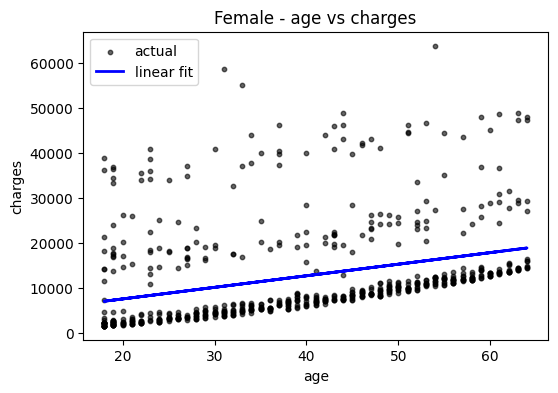

[Female] charges ~ bmi : 기울기(slope)=297.12, 절편(intercept)=3543.81


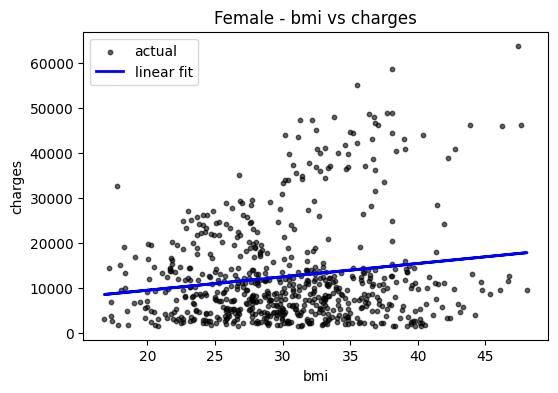

[Male] charges ~ age : 기울기(slope)=260.68, 절편(intercept)=3811.77


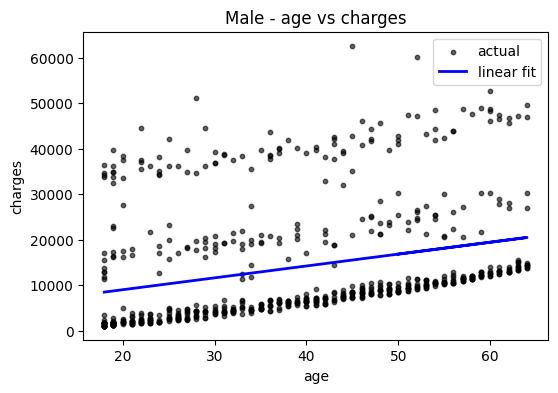

[Male] charges ~ bmi : 기울기(slope)=477.08, 절편(intercept)=-805.55


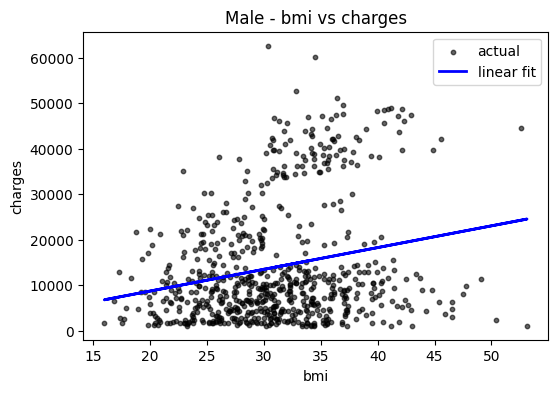

In [3]:
female = insurance[insurance['sex'] == 'female']
male = insurance[insurance['sex'] == 'male']

for group_data, label in [(female, 'Female'), (male, 'Male')]:
    group = InsuranceGroup(group_data, label)
    group.fit_and_plot()


## 결과 및 배운 점

- age·bmi 모두 charges와 **기울기가 양수**로 나와, 나이가 많거나 BMI가 높을수록 보험료가 올라가는 경향 자체는 확인할 수 있었다.
- 다만 산점도를 보면 점들이 넓게 흩어져 있어, age·bmi 단일 변수만으로는 보험료를 정확히 설명하기는 어렵다는 것도 함께 확인했다
  (흡연 여부 등 다른 변수의 영향이 더 클 수 있음 — 이번 실습 범위에는 포함하지 않음).
- Pandas로 조건에 맞는 행만 필터링(`insurance[insurance['sex']=='female']`)해서 그룹별로 나누어 분석하는 흐름과,
  반복되는 회귀·시각화 로직을 클래스로 묶어 재사용하는 경험을 할 수 있었다.
